# **Milestone 1: exploration phase**
### **1- Load dataset & apply the data processing used in the last module**

In [1]:
import pandas as pd
import os

os.chdir('/home/miguel/zrive-ds')

from src.module_3.metrics_fun import *

os.chdir('/home/miguel/zrive-ds')

dataset_path = "data/groceries/sampled_box_builder_df.csv"
df = pd.read_csv(dataset_path)
df = df[df.groupby('order_id')['outcome'].transform('sum') >= 5]

# Data processing (frecuencial categorical encoding and handling time variables) + 3 way split (the function for data processing is called inside the time_based split)
X_train, X_val, X_test, y_train, y_val, y_test = time_based_split(df, date_column='order_date', train_size=0.7, val_size=0.15, test_size=0.15)

: 

### **Define our metrics & baseline**

- **Metrics:**
As it was done throughout the previous module, the metrics that will be used are the plots of both the ROC curve and Precision-Recall curve. This election is made becaude we do not know which are the company's requirements for precision or recall rates, so the curves are a visual way to compare performances.

- **Baseline:**
The baseline for this exploration will be the linear model chosen after the exploration done in the previous module. This is because it won't make sense to build and implement a more complex model unless it shows arguably better results than a simple one. That linear model is imported as follows:

In [ ]:
import joblib

baseline_path = "models/module_3/20250214-153219_Linear Model.pkl"
baseline = joblib.load(baseline_path)

### **Try non-linear models**

In first place, we are going to implement a simple decision tree, and we are going to evaluate its results depending on its `max_depth` (the number of 'levels' that the tree can have).

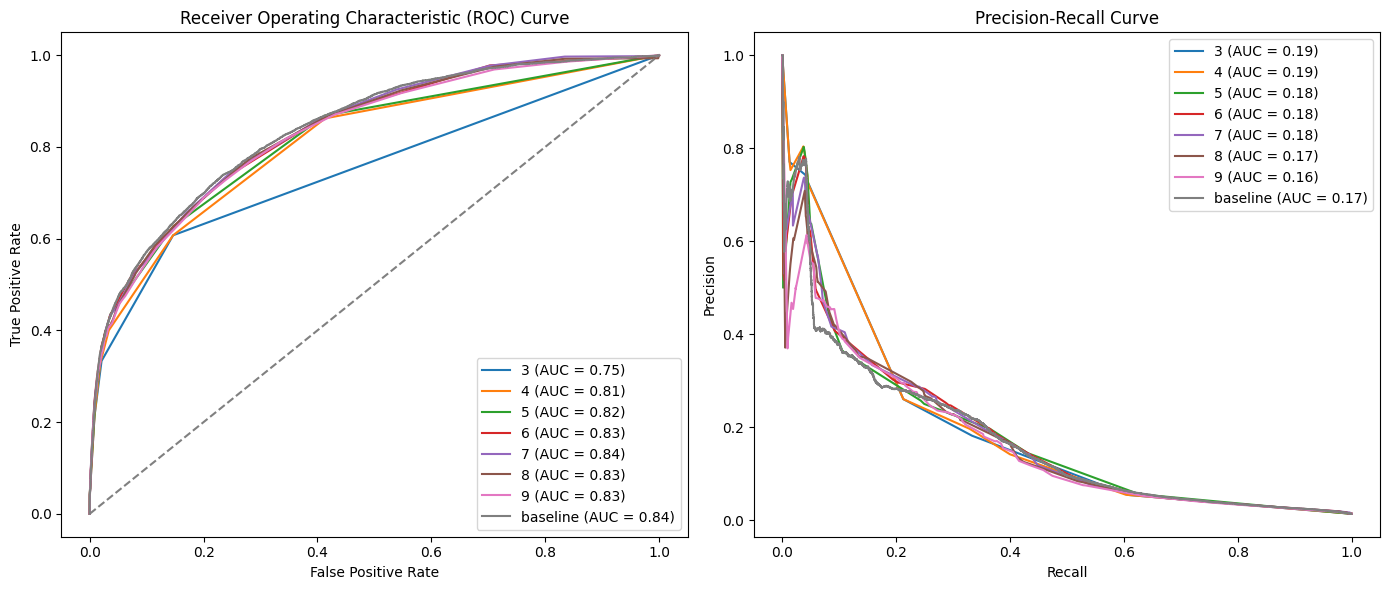

In [ ]:
from sklearn.tree import DecisionTreeClassifier
import numpy as np

initial_depth = 3
final_depth = 10
decision_trees = []

for depth in range(initial_depth, final_depth):
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree.fit(X_train, y_train)
    decision_trees.append(tree)

decision_trees.append(baseline)

plot_roc_pr_curves(decision_trees, X_val, y_val, model_names=np.append(np.arange(initial_depth, final_depth), 'baseline'))

Even though we can see some slight improves in performance (specially when we seek high values in precision) the curves obtained for simple decision trees do not provide a clear argument to be chosen over our baseline. Let's move on to the implementation of a Random Forest.

10
20
30
40
50
60
70
80
90
100


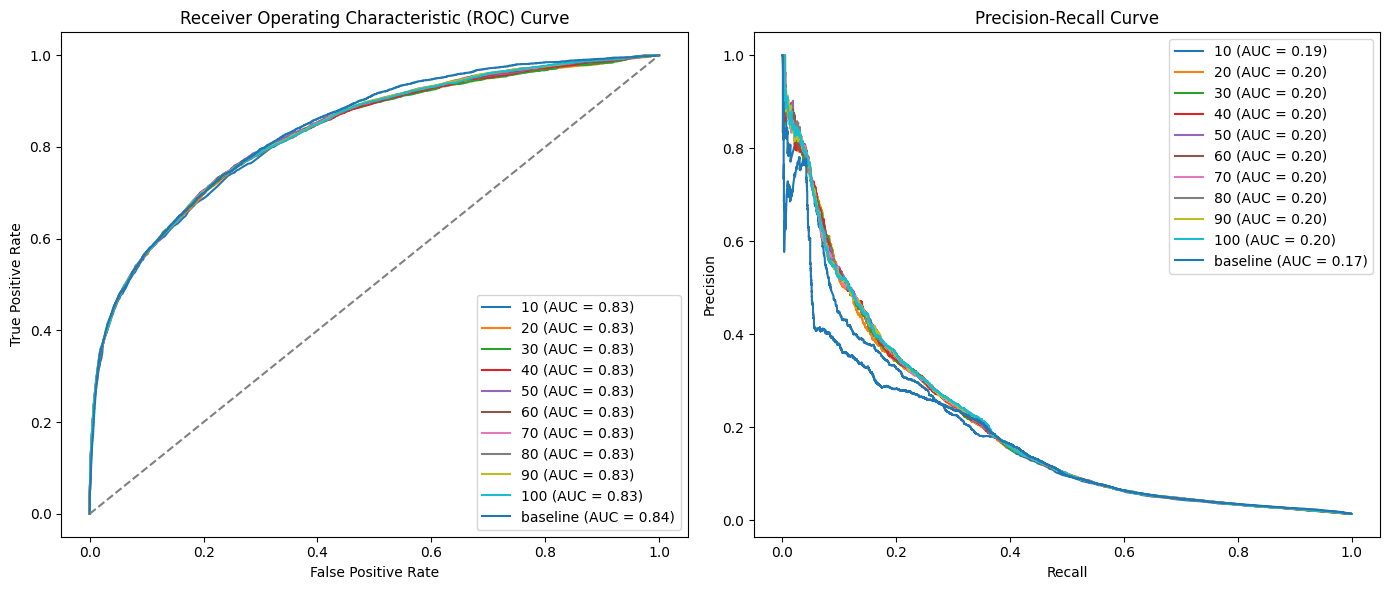

In [ ]:
from sklearn.ensemble import RandomForestClassifier

initial_trees = 10
final_trees = 100
step = 10 
random_forests = []

for n_trees in range(initial_trees, final_trees + 1, step):
    rf = RandomForestClassifier(n_estimators=n_trees, max_depth=5, random_state=42)
    rf.fit(X_train, y_train)
    random_forests.append(rf)

random_forests.append(baseline)

plot_roc_pr_curves(random_forests, X_val, y_val, model_names=np.append(np.arange(initial_trees, final_trees + 1, step), 'baseline'))

Looking at these curves, we see a larger improvement over the baseline defined. It can be clearly seen for precision values over 0.2, where the RandomForest models improve significantly their PR curves (producing more stable results as well). We can also appreciate that performance of Random Forests improves until 30/40 trees (`n_estimators`), where it becomes quite constant (as we saw in class, RF models stop improving at some point when we increes the tree number, but do not become worse, just computationally heavier).

After this, we will try some more sofisticated procedures in order to adjust both hyperparameters: `n_estimators` & `max_depth`. Let's try a Randomized Search.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': np.arange(50, 300, 50),
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'max_features': ['sqrt', 'log2']
}

rf = RandomForestClassifier(random_state=42)

# Perform Randomized Search
random_search = RandomizedSearchCV(rf, param_distributions=param_grid, n_iter=20, cv=3, scoring='roc_auc', n_jobs=-1, random_state=42)
random_search.fit(X_train, y_train)

best_rf = random_search.best_estimator_
print(f"Best parameters: {random_search.best_params_}")

plot_roc_pr_curves([baseline, random_search], X_val, y_val, model_names=['Baseline', 'Random Forest'])

: 